# <font size=6><b>Lec09. [실습]네이버쇼핑리뷰

In [1]:
import pandas as pd
import numpy as np

import re
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from konlpy.tag import Mecab
from konlpy.tag import Okt

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from collections import Counter
from tqdm import tqdm

from tensorflow.keras.layers import Embedding, Dense, GRU
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# data load

In [2]:
#urllib.request.urlretrieve("https://raw.githubusercontent.com/bab2min/corpus/master/sentiment/naver_shopping.txt", filename="lec09_ratings_total.txt")

In [3]:
df = pd.read_table("./dataset/lec09_ratings_total.txt", names=['ratings', 'reviews'])
df.head(2)

,ratings,reviews
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고


# 전처리 가공

In [4]:
print(df.shape)
df = df.dropna(subset="reviews") #결측
print(df.shape)

(200000, 2)
(200000, 2)


In [5]:
print(df.shape)
df = df.drop_duplicates(subset="reviews") #중복
print(df.shape)

(200000, 2)
(199908, 2)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199908 entries, 0 to 199999
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   ratings  199908 non-null  int64 
 1   reviews  199908 non-null  object
dtypes: int64(1), object(1)
memory usage: 4.6+ MB


## 라벨 긍부정 추가

In [7]:
df['label'] = np.select([df.ratings > 3], [1], default=0)
df.head(2)

,ratings,reviews,label
0,5,배공빠르고 굿,1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0


## 한글만

In [8]:
# 정규 표현식을 통한 한글 외 문자 제거
df['reviews'] = df['reviews'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True)
df.head(3)

,ratings,reviews,label
0,5,배공빠르고 굿,1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0
2,5,아주좋아요 바지 정말 좋아서개 더 구매했어요 이가격에 대박입니다 바느질이 조금 엉성...,1


## 불용어 처리

In [9]:
stop_words_list = stopwords.words('my_korean')
print('불용어 개수 :', len(stop_words_list))
print('불용어 10개 출력 :',stop_words_list[:10])

불용어 개수 : 595
불용어 10개 출력 : ['가', '가까스로', '가령', '각', '각각', '각자', '각종', '갖고말하자면', '같다', '같이']


In [10]:
mecab = Mecab(dicpath=r"C:/mecab/mecab-ko-dic")
#okt = Okt()

tokenized_data = []
for sentence in tqdm(df['reviews']):
    tokenized_sentence = mecab.morphs(sentence)          # 형태소 토큰화
    #tokenized_sentence = okt.morphs(sentence, stem=True)

    #불용어단어, 1글자 제거
    stopwords_removed_sentence = [
        word for word in tokenized_sentence
        if word not in stop_words_list ]
    tokenized_data.append(stopwords_removed_sentence)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199908/199908 [00:29<00:00, 6849.78it/s]


In [11]:
print( len(tokenized_data), len(df) )
tokenized_data[:2]

199908 199908


[['배공', '빠르', '고', '굿'],
 ['택배', '엉망', '용', '집', '밑', '층', '말', '도', '없이', '놔두', '고', '고']]

In [12]:
temp_list = []
for data in tokenized_data:
    temp_list.append(" ".join(data))
temp_list[:3]

['배공 빠르 고 굿',
 '택배 엉망 용 집 밑 층 말 도 없이 놔두 고 고',
 '아주 좋 아요 바지 정말 좋 아서 개 더 구매 했 어요 가격 대박 입니다 바느질 엉성 긴 편하 고 성비 최고 예요']

In [13]:
df['reviews2'] = temp_list
df.head(2)

,ratings,reviews,label,reviews2
0,5,배공빠르고 굿,1,배공 빠르 고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0,택배 엉망 용 집 밑 층 말 도 없이 놔두 고 고


## 토큰화, 패딩

In [14]:
def below_threshold_len(max_len, nested_list):
  count = 0
  for sentence in nested_list:
    if(len(sentence) <= max_len):
        count = count + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (count / len(nested_list))*100))


In [15]:
X = df['reviews2']
y = df['label']

In [16]:
max_len = 100
below_threshold_len(max_len, df['reviews2'])

전체 샘플 중 길이가 100 이하인 샘플의 비율: 94.51147527862817


In [17]:
X80, X20, y80, y20 = train_test_split(X, y, test_size=0.2, random_state=8745, stratify=y)

In [18]:
tk = Tokenizer(oov_token='OOV')
tk.fit_on_texts(X80)                        #-------------------[1]문장/단어 자르기
# print(tk.word_index)                      #-----------사전확인 : 단어인덱스
# print(tk.word_counts)                     #-----------사전확인 : 단어빈도

## 등장빈도 1회 단어버리기

In [19]:
threshold = 2
total_cnt = len(tk.word_index) # 사전크기(단어의 수)
total_freq = 0                 # 훈련 데이터의 전체 단어 빈도수 총 합
rare_cnt = 0                   # 등장 빈도수가 threshold보다 작은 : 1번 등장한 단어의 개수를 카운트
rare_freq = 0                  # 등장 빈도수가 threshold보다 작은 : 1번 등장한 단어의 빈도수의 총 합

# 단어와 빈도수의 쌍(pair)을 key와 value로 받는다.
for key, value in tk.word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기 :',total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)


단어 집합(vocabulary)의 크기 : 41084
등장 빈도가 1번 이하인 희귀 단어의 수: 18759
단어 집합에서 희귀 단어의 비율: 45.660110992113715
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 0.7500164924464595


In [20]:
# vocab_sorted = sorted(tk.word_counts.items(), key = lambda x:x[1], reverse = True)
# vocab_sorted = vocab_sorted[:19709]
# len(vocab_sorted[:19709])
#print(vocab_sorted[:19709])

In [21]:
# 0번 패딩 토큰과 1번 OOV 토큰을 고려하여 +2
vocab_size = total_cnt - rare_cnt + 2
print('단어 집합의 크기 :',vocab_size)

tokenizer = Tokenizer(vocab_size, oov_token = 'OOV') #단어를 "빈도순으로 자동 정렬해서 index 부여"
tokenizer.fit_on_texts(X80)
X80 = tokenizer.texts_to_sequences(X80)
X20 = tokenizer.texts_to_sequences(X20)

max_len =100
X80 = pad_sequences(X80, maxlen=max_len, padding='pre')
X20 = pad_sequences(X20, maxlen=max_len, padding='pre')
df.head(3)

단어 집합의 크기 : 22327


,ratings,reviews,label,reviews2
0,5,배공빠르고 굿,1,배공 빠르 고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0,택배 엉망 용 집 밑 층 말 도 없이 놔두 고 고
2,5,아주좋아요 바지 정말 좋아서개 더 구매했어요 이가격에 대박입니다 바느질이 조금 엉성...,1,아주 좋 아요 바지 정말 좋 아서 개 더 구매 했 어요 가격 대박 입니다 바느질 엉...


# eda

## 타겟 불균형 체크

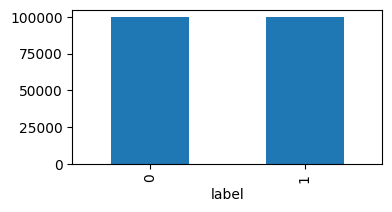

In [22]:
plt.figure(figsize=(4,2))
df['label'].value_counts().plot(kind = 'bar')
plt.show()

## 단어 길이 체크

긍정 리뷰의 평균 길이 : 35.48343721549128
부정 리뷰의 평균 길이 : 45.27097193737182
리뷰의 평균 길이 : 40.377253536626846


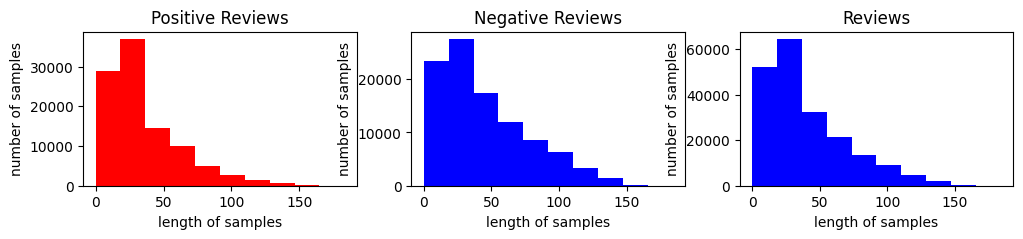

In [23]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(12,2))
text_len = df[df['label']==1]['reviews2'].map(lambda x: len(x))
ax1.hist(text_len, color='red')
ax1.set_title('Positive Reviews')
ax1.set_xlabel('length of samples')
ax1.set_ylabel('number of samples')
print('긍정 리뷰의 평균 길이 :', np.mean(text_len))

text_len = df[df['label']==0]['reviews2'].map(lambda x: len(x))
ax2.hist(text_len, color='blue')
ax2.set_title('Negative Reviews')
ax2.set_xlabel('length of samples')
ax2.set_ylabel('number of samples')
print('부정 리뷰의 평균 길이 :', np.mean(text_len))

text_len = df['reviews2'].map(lambda x: len(x))
ax3.hist(text_len, color='blue')
ax3.set_title('Reviews')
ax3.set_xlabel('length of samples')
ax3.set_ylabel('number of samples')
print('리뷰의 평균 길이 :', np.mean(text_len))
plt.show()

## 워드 클라우드

In [24]:
#! pip install wordcloud

In [26]:
negative_words = np.hstack(df[df.label == 0]['reviews2'].values) # 부정단어 20
positive_words = np.hstack(df[df.label == 1]['reviews2'].values) # 긍정단어 20

print(type(negative_words), negative_words.shape)

negative_word_count = Counter(negative_words)
print(negative_word_count.most_common(10))

print("--"*20)
positive_word_count = Counter(positive_words)
print(positive_word_count.most_common(10))

<class 'numpy.ndarray'> (99955,)
[('재 구매', 27), ('배송 너무 느려요', 19), ('그냥 그래요', 12), ('', 11), ('좋 아요', 9), ('잘 받 았', 8), ('그래요', 8), ('배송 느려요', 8), ('별로 에요', 8), ('배송 늦 어요', 8)]
----------------------------------------
[('재 구매', 30), ('좋 아요', 18), ('좋', 17), ('좋 네요', 8), ('만족 합니다', 8), ('감사 합니다', 8), ('잘 받 았', 8), ('배송 빨 라요', 7), ('빠른 배송 감사 합니다', 7), ('굿', 6)]


In [27]:
from wordcloud import WordCloud

In [28]:
def MY_CLOUD_CHART(data):
    wc = WordCloud(font_path='C:/Windows/Fonts/malgun.ttf'
                   ,background_color="white", max_font_size=60)
    
    try : 
        if type(data) == str:
            cloud = wc.generate(data)
        else :
            cloud = wc.generate_from_frequencies(dict(data))
        # cloud.to_file('test.jpg')
        plt.figure(figsize=(5, 3))
        plt.axis('off')
        plt.imshow(cloud)
        plt.show()
    except:
        print("파라미터는 str 또는 dict만 지원합니다")

In [29]:
# LIST --> String로 변환
mylist = ['a','b','c']
print( " ".join(mylist) )

# String --> LIST로 변환
mystr = "a b c"
print(mystr.split(" "))

a b c
['a', 'b', 'c']


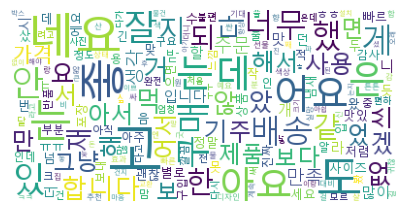

In [30]:
MY_CLOUD_CHART(tk.word_counts)

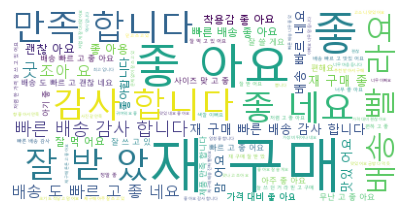

In [31]:
MY_CLOUD_CHART(positive_word_count)

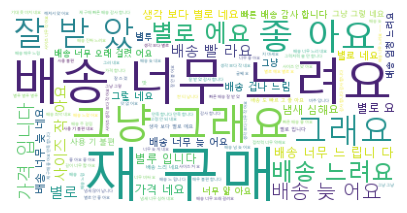

In [32]:
MY_CLOUD_CHART(negative_word_count)

# <B>긍부정 분류 모델
* <B>OOV : 0 = padding, 1 = OOV , 2부터 실제 단어

In [33]:
df.head(2)

,ratings,reviews,label,reviews2
0,5,배공빠르고 굿,1,배공 빠르 고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0,택배 엉망 용 집 밑 층 말 도 없이 놔두 고 고


In [37]:
embedding_dim = 100
hidden_units = 128

model = Sequential()
model.add(Embedding(vocab_size, embedding_dim, mask_zero=True))  #값이 0인 토큰을 "패딩으로 간주하고 무시" --> RNN / LSTM / GRU / Transformer padding=0 연산에서 제외
model.add(GRU(hidden_units))
model.add(Dense(1, activation='sigmoid'))

MY_STOP = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
MY_CHECK = ModelCheckpoint('best_model.keras', monitor='val_acc', mode='max', save_best_only=True)

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
fit_res= model.fit(X80, y80, epochs=15, callbacks=[MY_STOP, MY_CHECK], batch_size=128, validation_data=(X20,y20))

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 144s 114ms/step - accuracy: 0.8868 - loss: 0.2952 - val_accuracy: 0.9024 - val_loss: 0.2647
Epoch 2/15


C:\IT\workspace_ptyhon\.venv\lib\site-packages\keras\src\callbacks\model_checkpoint.py:276: UserWarning: Can save best model only with val_acc available.
  if self._should_save_model(epoch, batch, logs, filepath):


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 113ms/step - accuracy: 0.9126 - loss: 0.2394 - val_accuracy: 0.9126 - val_loss: 0.2363
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 141s 113ms/step - accuracy: 0.9220 - loss: 0.2155 - val_accuracy: 0.9163 - val_loss: 0.2274
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 113ms/step - accuracy: 0.9280 - loss: 0.2016 - val_accuracy: 0.9186 - val_loss: 0.2199
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 114ms/step - accuracy: 0.9319 - loss: 0.1911 - val_accuracy: 0.9196 - val_loss: 0.2179
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 143s 114ms/step - accuracy: 0.9353 - loss: 0.1824 - val_accuracy: 0.9177 - val_loss: 0.2229
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 144s 115ms/step - accuracy: 0.9396 - loss: 0.1739 - val_accuracy: 0.9203 - val_loss: 0.2243
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 143s 115ms/step - accuracy: 0.9432 - loss: 0.1655 - val_accuracy: 0.9199 - val_loss: 0.2192
Epoch 9/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 144s 115ms/step - accuracy: 0.9

In [39]:
fit_res.epoch

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [40]:
fit_res.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

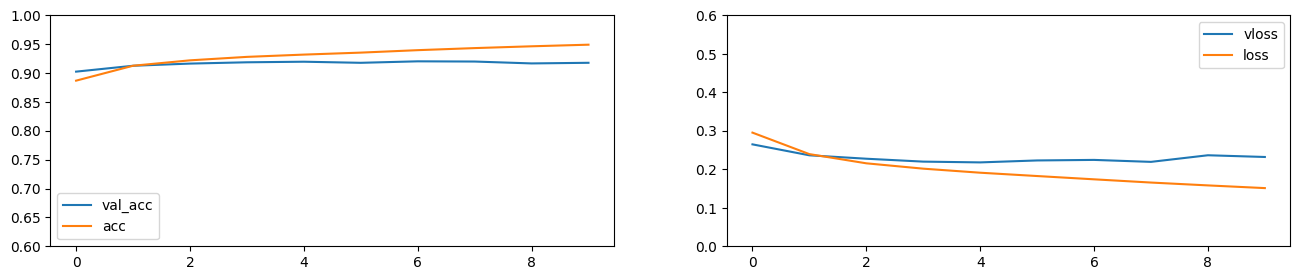

In [41]:
plt.figure(figsize=(16,3))
plt.subplot(1,2,1)
vacc = fit_res.history["val_accuracy"]
acc  = fit_res.history["accuracy"]
plt.ylim(0.6, 1.0)  # y축
plt.plot(fit_res.epoch, vacc , label="val_acc")
plt.plot(fit_res.epoch, acc  , label="acc")
plt.legend()

plt.subplot(1,2,2)
vloss = fit_res.history["val_loss"]
loss = fit_res.history["loss"]
plt.ylim(0.0, 0.6)  # y축 
plt.plot(fit_res.epoch, vloss , label="vloss")
plt.plot(fit_res.epoch,loss  , label="loss")
plt.legend()
plt.show()

# 예측

In [42]:
from tensorflow.keras.models import load_model
best_model = load_model("lec09_best_model_9541_1379.keras")

In [43]:
def MY_PREDICT(new_sentence):
  new_sentence = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣 ]','', new_sentence)
  #new_sentence = okt.morphs(new_sentence, stem=True)
  new_sentence = mecab.morphs(new_sentence)               # 형태소 토큰화
  new_sentence = [word for word in new_sentence if word not in stop_words_list] # and len(word)>1] # 불용어 제거

  encoded = tk.texts_to_sequences([new_sentence])
  pad_new = pad_sequences(encoded, maxlen=100, padding="pre" )

  score = float(best_model.predict(pad_new))
  if(score > 0.5):
    print("{:.2f}% 확률로 긍정 리뷰입니다.".format(score * 100))
  else:
    print("{:.2f}% 확률로 부정 리뷰입니다.".format((1 - score) * 100))

In [44]:
MY_PREDICT('진짜 배송도 늦고 개짜증나네요. 뭐 이런 걸 상품이라고 만듬?')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
99.98% 확률로 부정 리뷰입니다.


C:\Users\PC\AppData\Local\Temp\ipykernel_8356\390088882.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(best_model.predict(pad_new))


In [45]:
MY_PREDICT('이 상품 진짜 좋아요... 저는 강추합니다. 대박')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
98.46% 확률로 긍정 리뷰입니다.


C:\Users\PC\AppData\Local\Temp\ipykernel_8356\390088882.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(best_model.predict(pad_new))
